In [1]:
!conda env list



# conda environments:
#
# * -> active
# + -> frozen
base                 *   /home/sayan/miniconda3
pytorch-env              /home/sayan/miniconda3/envs/pytorch-env



In [2]:
import os
print(os.environ['CONDA_DEFAULT_ENV'])

base


In [3]:
import datetime 
from functools import partial 
from glob import glob
import json 
import math 
import multiprocessing 
import os
from pathlib import Path
import random
from typing import Any, Dict, Optional 

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from distinctipy import distinctipy
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

In [5]:
import pandas as pd
pd.set_option('max_colwidth', None)  # Do not truncate the contents of cells in the DataFrame
pd.set_option('display.max_rows', None)  # Display all rows in the DataFrame
pd.set_option('display.max_columns', None)  # Display all columns in the DataFrame


In [6]:
import torch
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtnt.utils import get_module_summary
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes, Mask
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.v2  as transforms
from torchvision.transforms.v2 import functional as TF

# Import Mask R-CNN
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


In [7]:
seed = 1234 
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
set_seed(seed) 

In [8]:
def get_torch_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_torch_device()
dtype = torch.float32
device, dtype

(device(type='cuda'), torch.float32)

In [9]:
# The name for the project
project_name = f"pytorch-mask-r-cnn-instance-segmentation"

# The path for the project folder
project_dir = Path(f"./{project_name}/")

# Create the project directory if it does not already exist
project_dir.mkdir(parents=True, exist_ok=True)

# Define path to store datasets
dataset_dir = Path("./Datasets/")
# Create the dataset directory if it does not exist
dataset_dir.mkdir(parents=True, exist_ok=True)

pd.Series({
    "Project Directory:": project_dir, 
    "Dataset Directory:": dataset_dir
}).to_frame().style.hide(axis='columns')

Project Directory:,pytorch-mask-r-cnn-instance-segmentation
Dataset Directory:,Datasets


In [17]:
# Set the name of the dataset
dataset_name = 'pytorch-for-information-extraction'

# Construct the GitHub repository name 
gh_repo = f'cj-mills/{dataset_name}'

# Create the path to the directory where the dataset will be extracted
dataset_path = Path(f'{dataset_dir}/{dataset_name}/code/datasets/detection/student-id/')

pd.Series({
    "GitHub Repository:": gh_repo, 
    "Dataset Path:": dataset_path
}).to_frame().style.hide(axis='columns')

GitHub Repository:,cj-mills/pytorch-for-information-extraction
Dataset Path:,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id


In [18]:
#Dataset
!git clone {f 'https://github.com/cj-mills/pytorch-for-information-extraction'} {Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id}

fatal: Too many arguments.

usage: git clone [<options>] [--] <repo> [<dir>]

    -v, --verbose         be more verbose
    -q, --quiet           be more quiet
    --progress            force progress reporting
    --reject-shallow      don't clone shallow repository
    -n, --no-checkout     don't create a checkout
    --bare                create a bare repository
    --mirror              create a mirror repository (implies bare)
    -l, --local           to clone from a local repository
    --no-hardlinks        don't use local hardlinks, always copy
    -s, --shared          setup as shared repository
    --recurse-submodules[=<pathspec>]
                          initialize submodules in the clone
    --recursive ...       alias of --recurse-submodules
    -j, --jobs <n>        number of submodules cloned in parallel
    --template <template-directory>
                          directory from which templates will be used
    --reference <repo>    reference repository
    --refere

In [ ]:
# import os
# print(os.getcwd())

In [34]:
# def get_img_files(dataset_path):
#     image_data = []

#     for filename in os.listdir(dataset_path):
#         if filename.endswith(".jpg") or filename.endswith(".png"):
#             img_path = os.path.join(dataset_path, filename)
#             img = Image.open(img_path).convert("RGB")
#             img_array = np.array(img)
#             image_data.append(img_array)
#     image_data = np.array(image_data)
#     return image_data

def get_img_files(folder_path):
    folder_path = Path(folder_path)
    img_files = [f for f in folder_path.glob('*') 
                 if f.suffix.lower() in ['.jpg', '.png']]
    return sorted(img_files)

In [26]:
import os
for item in os.listdir('Datasets'):
    print(item)

pytorch-for-information-extraction


In [35]:
img_file_paths = get_img_files(dataset_path)

# Get a list of JSON files in the dataset
annotation_file_paths = list(dataset_path.glob('*.json'))

# Display the names of the folders using a Pandas DataFrame
pd.DataFrame({"Image File": [file.name for file in img_file_paths], 
              "Annotation File":[file.name for file in annotation_file_paths]}).head()

,Image File,Annotation File
0,10001.jpg,10023.json
1,10002.jpg,10026.json
2,10003.jpg,10144.json
3,10004.jpg,10111.json
4,10005.jpg,10054.json


In [37]:
img_dict = {file.stem : file for file in img_file_paths}
print(f"Number of Images: {len(img_dict)}")

pd.DataFrame.from_dict(img_dict, orient = 'index').head()

Number of Images: 150


,0
10001,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10001.jpg
10002,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10002.jpg
10003,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10003.jpg
10004,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10004.jpg
10005,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10005.jpg


In [40]:
cls_dataframes = (pd.read_json(f, orient = 'index').transpose() for f in tqdm(annotation_file_paths))
annotation_df = pd.concat(cls_dataframes, ignore_index = False)

annotation_df['index'] = annotation_df.apply(lambda row: row['imagePath'].split('.')[0], axis = 1)
annotation_df = annotation_df.set_index('index')

# Keep only the rows that correspond to the filenames in the 'img_dict' dictionary
annotation_df = annotation_df.loc[list(img_dict.keys())]

# Print the first 5 rows of the DataFrame
annotation_df.head()


  0%|          | 0/150 [00:00<?, ?it/s]

,version,flags,shapes,lineColor,fillColor,imagePath,imageData,imageHeight,imageWidth
index,,,,,,,,,
10001,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[19.190476190476204, 244.76190476190476], [23.0, 233.33333333333331], [385.8571428571428, 132.38095238095238], [400.1428571428571, 135.23809523809524], [468.71428571428567, 353.3333333333333], [466.80952380952374, 362.85714285714283], [97.28571428571428, 478.0952380952381], [81.09523809523807, 474.2857142857143]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10001.jpg,,640,480
10002,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[21.095238095238102, 183.33333333333334], [231.41269841269843, 88.09523809523809], [450.46031746031747, 347.6190476190476], [475.06349206349205, 376.1904761904762], [478.2380952380952, 388.8888888888889], [301.25396825396825, 532.5396825396825], [271.0952380952381, 556.3492063492064], [255.22222222222223, 541.2698412698413], [242.52380952380952, 534.9206349206349], [25.85714285714286, 199.20634920634922]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10002.jpg,,640,480
10003,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[138.23809523809524, 71.42857142857143], [407.7619047619047, 31.428571428571427], [418.2380952380952, 39.047619047619044], [422.04761904761904, 539.047619047619], [407.7619047619047, 552.3809523809524], [112.52380952380952, 519.047619047619], [98.23809523809524, 505.71428571428567]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10003.jpg,,640,480
10004,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[119.20529801324503, 218.54304635761588], [440.3973509933775, 184.7682119205298], [445.0331125827814, 190.72847682119206], [391.3907284768212, 366.2251655629139], [384.7682119205298, 372.18543046357615], [250.33112582781456, 401.3245033112583], [82.11920529801324, 446.3576158940397], [76.82119205298014, 441.72185430463577], [49.66887417218544, 239.73509933774835], [107.28476821192052, 228.47682119205297]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10004.jpg,,640,480
10005,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[41.18840579710144, 218.8405797101449], [41.18840579710144, 209.42028985507244], [52.78260869565216, 201.44927536231882], [224.52173913043475, 142.75362318840578], [359.30434782608694, 89.85507246376811], [367.99999999999994, 92.02898550724638], [462.2028985507246, 275.3623188405797], [369.4492753623188, 348.5507246376811], [199.88405797101444, 472.463768115942], [191.91304347826082, 471.01449275362313]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10005.jpg,,640,480


In [41]:
shapes_df = annotation_df['shapes'].explode().to_frame().shapes.apply(pd.Series)
class_names = shapes_df['label'].unique().tolist()

pd.DataFrame(class_names)

,0
0,student_id


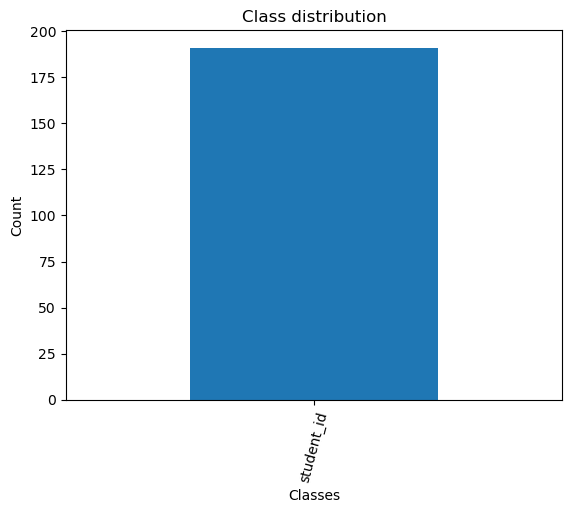

In [42]:
class_counts = shapes_df['label'].value_counts()

# Plot the distribution
class_counts.plot(kind='bar')
plt.title('Class distribution')
plt.ylabel('Count')
plt.xlabel('Classes')
plt.xticks(range(len(class_counts.index)), class_names, rotation=75)  # Set the x-axis tick labels
plt.show()

In [47]:
#adding a background class
class_names = ['background']+class_names
pd.DataFrame(class_names)


,0
0,background
1,student_id


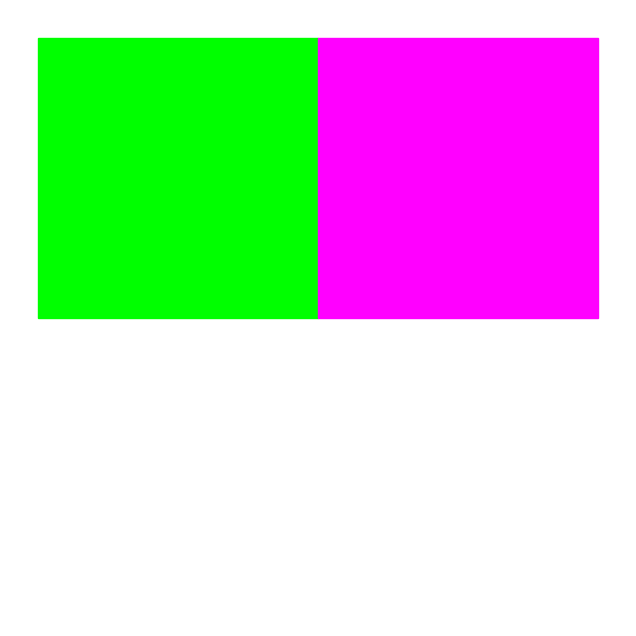

In [49]:
# Generate a list of colors with a length equal to the number of labels
colors = distinctipy.get_colors(len(class_names))

int_colors = [tuple(int(c*255) for c in color) for color in colors]
distinctipy.color_swatch(colors)

In [50]:
# # Set the name of the font file
# font_file = 'KFOlCnqEu92Fr1MmEU9vAw.ttf'

# # Download the font file
# download_file(f"https://fonts.gstatic.com/s/roboto/v30/{font_file}", "./")

NameError: name 'download_file' is not defined

In [51]:
draw_bboxes = partial(draw_bounding_boxes, fill=False, width=2, font=font_file, font_size=25)
